# Download and prepare `LW_IN` (2005-2025)

**notebook version**: `1` (20 Jul 2026)

## ℹ️ About this notebook

Downloads screened incoming longwave radiation `LW_IN` from the InfluxDB database, merges the two
data sources into one continuous series, applies the 2012 corrections and stores the result to the
external data folder.

Same structure as notebooks `01` (`SW_IN`), `02` (`TA`), `03` (`PPFD_IN`) and `05` (`PA`), with
these differences:

1. **No gap-filling.** The measured record is 98.96% complete, so the series is exported as
   measured, as in notebook `05`. See "No gap-filling here" below.
2. **No second sensor of any kind.** There is no NABEL pyrgeometer, so unlike `01`, `02` and `05`
   there is no independent instrument to validate against. This has a real consequence for the 2012
   corrections, spelled out where they are applied — **the evidence there is weaker than in any of
   the other notebooks, and this one says so rather than implying otherwise.**
3. **The record starts 2005-09-14**, when the sensor starts, so the index does not begin at
   2004-01-01.
4. **No unit break** (everything is `W m-2`), unlike `PA`. What this notebook checks instead is
   that the **raw source variable changes** at the 2021/2022 boundary — see below.

**Output column:**

- `LW_IN_T1_47_1` — incoming longwave radiation in **W m-2**, measured, corrected, with genuine
  gaps left as `NaN`

There is **no `FLAG_..._ISFILLED` column**: nothing is filled, so every non-null record is a
measurement and every gap is a real gap.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

# Info about data sources

- `LW_IN_T1_47_1` — the exported variable, and **the only longwave series this notebook reads**.
  Tower 1, 47 m. `mst` (2005-2021) and `diive` (2022-2025). The two do not overlap.
- `TA_T1_47_1` — air temperature, downloaded as a **diagnostic only**. Longwave and temperature are
  physically tied (`LW_IN ~ eps * sigma * TA^4`), which gives a sanity check that needs no second
  pyrgeometer. Never exported.
- **There is no NABEL longwave sensor**, and no other independent pyrgeometer at the site.
  `LW_IN_BC_M1_2_1` exists but is *below canopy* and starts in 2024, so it measures a different
  quantity over a different period and is not usable as a reference.

Legend:
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⚠️ The raw source changes at the 2021/2022 boundary

`PA` (notebook `05`) had a unit break at this boundary. `LW_IN` does not — every series is stored
in `W m-2`. It has a subtler discontinuity risk instead, visible in the database tags:

| data version | period | `raw_varname` |
|---|---|---|
| `meteoscreening_mst` | 2005-09-14 -> 2021-12-31 | `LW_IN_AVG_T1_47_1` |
| `meteoscreening_diive` | 2022-01-01 -> 2025-12-31 | `LW_IN_COR_T1_47_1_Avg` |

So the column called `LW_IN_T1_47_1` is fed by the **uncorrected** raw variable until 2021 and by a
**corrected** one from 2022. For a pyrgeometer, such a correction usually accounts for the
instrument's own body/dome temperature, which for some sensors shifts the value by tens of
`W m-2`. If that were the case here, the exported series would contain a processing step change in
the middle — the same class of error as a unit break: invisible in a plot of the whole record, but
wrong.

The notebook therefore **checks the boundary rather than assuming it is clean**, using air
temperature: longwave is tightly tied to `TA`, so if the level step at 2021/2022 is no larger than
the temperature change of those years predicts, there is no room left for a processing step. That
check is below and has to pass.

(The database also holds a separately archived `..._COR_...` field for part of the record. It is
deliberately **not read anywhere in this notebook** — the only longwave series used is
`LW_IN_T1_47_1`.)

The units tag is also verified, mostly as a cheap guard: one of the `diive` series carries the
placeholder `-not-given-` alongside the real `W m-2`, so the check strips placeholders and then
requires exactly one real unit to remain.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

# ⚙️ Settings

## Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "LW_IN_T1_47_1"          # exported variable, tower 47 m; the ONLY longwave series read here
TA_COL = "TA_T1_47_1"             # air temperature, diagnostics only

# LW_IN measurements start 2005-09-14. The exported index starts there rather than at 2004-01-01:
# there is no longwave before it and none is reconstructed.
RECORD_START = '2005-09-14'
RECORD_END = '2025-12-31'

OUTNAME = "06_METEO_LW_IN_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-20 02:45:43
diive version: v0.91.0


## 🧭 Guards

Two cheap checks that run on every source before it is used.

`LW_IN_PLAUSIBLE_WM2` is deliberately generous (100-550 W m-2). Downwelling longwave at a
mid-latitude site spans roughly 120-500 W m-2; the observed range over this whole record is
135-442 W m-2. The band only has to be wide enough never to reject real weather and tight enough to
catch a gross error such as a different quantity or a scaling mistake.

Unlike notebook `05` there is **no unit harmonisation here**, because there is no unit break to
harmonise: every series is already `W m-2`. Converting nothing is the correct amount of machinery.

In [3]:
# Physically plausible downwelling longwave at this site.
LW_IN_PLAUSIBLE_WM2 = (100.0, 550.0)
EXPECTED_UNIT = 'W m-2'
NOT_GIVEN = '-not-given-'   # placeholder the database uses when a unit tag was never filled in


def check_unit(declared_units: list, source: str) -> str:
    """Verify the database's unit tags for a series say W m-2, ignoring placeholders.

    A series can carry more than one tag value (e.g. when the tag changed over time, or was
    left unset for part of the record). Placeholders are dropped; exactly one real unit must
    remain, and it must be the expected one.
    """
    real = [u for u in declared_units if u != NOT_GIVEN]
    if len(set(real)) != 1:
        raise ValueError(f"{source}: expected exactly one real unit tag, found {declared_units}.")
    if real[0] != EXPECTED_UNIT:
        raise ValueError(f"{source}: unit is '{real[0]}', expected '{EXPECTED_UNIT}'.")
    return real[0]


def check_range(series: pd.Series, source: str) -> pd.Series:
    """Verify every value is physically plausible downwelling longwave, and report the series."""
    lo, hi = LW_IN_PLAUSIBLE_WM2
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data.")
    if not (lo <= s.min() and s.max() <= hi):
        raise ValueError(f"{source}: range {s.min():.1f}..{s.max():.1f} W m-2 is outside the "
                         f"plausible {lo}..{hi} W m-2.")
    print(f"  {source:<22} n={len(s):>7,}   median {float(s.median()):7.2f}   "
          f"range {s.min():.1f}..{s.max():.1f} W m-2")
    return series

## 🔌 Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

# ⬇️ Download

Three series: the target from both of its data versions, and air temperature for the boundary and
physical sanity checks. Only the target is exported.

In [5]:
%%time

BUCKET = 'ch-lae_processed'


def download(measurement, fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[measurement], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


mst_lw = download('LW', [TARGET], '2004-01-01 00:00:01', '2022-01-01 00:00:01',
                  'meteoscreening_mst')
diive_lw = download('LW', [TARGET], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

# Air temperature, diagnostics only.
mst_ta = download('TA', [TA_COL], '2004-01-01 00:00:01', '2022-01-01 00:00:01',
                  'meteoscreening_mst')
diive_ta = download('TA', [TA_COL], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_lw[TARGET].notna().sum():,} records")
print(f"diive {TARGET}: {diive_lw[TARGET].notna().sum():,} records")
print(f"TA (mst + diive): {mst_ta[TA_COL].notna().sum():,} + {diive_ta[TA_COL].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_IN_T1_47_1'] from measurements ['LW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_IN_T1_47_1'] from measurements ['LW'], 
data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_T1_47_1'] from measurements ['TA'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_T1_47_1'] from measurements ['TA'], 
data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

mst   LW_IN_T1_47_1: 282,159 records
diive LW_IN_T1_47_1: 70,012 records
TA (mst + diive): 300,268 + 70,012 records
CPU times: total: 11.7 s
Wall time: 16.8 s


In [6]:
# Tags straight from the database, including the unit and the raw variable each series came from.
def field_tags(field, measurement, data_version):
    return dbc.show_field_overview(bucket=BUCKET, measurement=measurement, field=field,
                                   data_version=data_version, verbose=False)['tags']


_tags_mst = field_tags(TARGET, 'LW', 'meteoscreening_mst')
_tags_diive = field_tags(TARGET, 'LW', 'meteoscreening_diive')

display(pd.DataFrame({
    'units': [_tags_mst['units'], _tags_diive['units']],
    'raw_varname': [_tags_mst['raw_varname'], _tags_diive['raw_varname']],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)']))

print("Note the raw_varname change between the two data versions of the SAME column - that is "
      "what the boundary check below is about.")

,units,raw_varname
LW_IN_T1_47_1 (mst),[W m-2],[LW_IN_AVG_T1_47_1]
LW_IN_T1_47_1 (diive),"[-not-given-, W m-2]",[LW_IN_COR_T1_47_1_Avg]


Note the raw_varname change between the two data versions of the SAME column - that is what the boundary check below is about.


## Unit and range checks

In [7]:
print("Unit tags (placeholders stripped):")
for _tags, _src in [(_tags_mst, f'{TARGET} (mst)'), (_tags_diive, f'{TARGET} (diive)')]:
    print(f"  {_src:<26} {_tags['units']} -> {check_unit(_tags['units'], _src)}")

print("\nRange checks:")
check_range(mst_lw[TARGET], f'{TARGET} (mst)')
check_range(diive_lw[TARGET], f'{TARGET} (diive)')

Unit tags (placeholders stripped):
  LW_IN_T1_47_1 (mst)        ['W m-2'] -> W m-2
  LW_IN_T1_47_1 (diive)      ['-not-given-', 'W m-2'] -> W m-2

Range checks:
  LW_IN_T1_47_1 (mst)    n=282,159   median  313.53   range 135.4..441.8 W m-2
  LW_IN_T1_47_1 (diive)  n= 70,012   median  325.16   range 191.1..439.1 W m-2


TIMESTAMP_MIDDLE
2022-01-01 00:15:00    281.339657
2022-01-01 00:45:00    280.357413
2022-01-01 01:15:00    279.863157
2022-01-01 01:45:00    280.836867
2022-01-01 02:15:00    280.860203
                          ...    
2025-12-31 21:45:00    210.420480
2025-12-31 22:15:00    210.648200
2025-12-31 22:45:00    211.147057
2025-12-31 23:15:00    211.392263
2025-12-31 23:45:00    211.581177
Freq: 30min, Name: LW_IN_T1_47_1, Length: 70128, dtype: float64

### The guards actually guard

A check that never fires is not a check, so both failure paths are exercised here.

In [8]:
for _bad, _why in [(['kW m-2'], 'wrong unit'), (['W m-2', 'MJ m-2'], 'two real units')]:
    try:
        check_unit(_bad, 'negative control')
        raise AssertionError(f"check_unit accepted {_bad} - the guard is broken.")
    except ValueError as exc:
        print(f"OK ({_why}): {exc}")

try:
    check_range(mst_lw[TARGET] * 10, 'negative control')
    raise AssertionError("check_range accepted a 10x scaled series - the guard is broken.")
except ValueError as exc:
    print(f"OK (scaled x10): {exc}")

OK (wrong unit): negative control: unit is 'kW m-2', expected 'W m-2'.
OK (two real units): negative control: expected exactly one real unit tag, found ['W m-2', 'MJ m-2'].
OK (scaled x10): negative control: range 1354.5..4417.8 W m-2 is outside the plausible 100.0..550.0 W m-2.


***

# 🔍 Boundary check: does the raw source change matter?

## Is the level step at the boundary explained by weather?

The raw source variable changes at 2021/2022, so the exported series has to be shown not to step
there. The check uses air temperature, which is independent of how the longwave signal was
processed.

Longwave and temperature are tied by `LW_IN = eps * sigma * TA^4`, where `eps` is the bulk apparent
emissivity of the sky. Differentiating gives `dLW/dTA = 4 * eps * sigma * TA^3`, about
4.4 W m-2 per K at this site. If the observed step matches what the temperature change predicts,
the step is weather, not instrumentation.

In [9]:
SIGMA = 5.670374419e-8  # Stefan-Boltzmann, W m-2 K-4

_idx_full = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00', freq='30min',
                          name='TIMESTAMP_MIDDLE')
_lw_all = mst_lw[TARGET].reindex(_idx_full).combine_first(diive_lw[TARGET].reindex(_idx_full))
ta_diag = mst_ta[TA_COL].reindex(_idx_full).combine_first(diive_ta[TA_COL].reindex(_idx_full))

# Bulk apparent sky emissivity, used here and again for the 2012 diagnostics.
emissivity = _lw_all / (SIGMA * (ta_diag + 273.15) ** 4)
EMIS_MEDIAN = float(emissivity.loc['2006':'2020'].median())
_q = emissivity.loc['2006':'2020'].dropna()
print(f"apparent sky emissivity 2006-2020: median {EMIS_MEDIAN:.3f}  "
      f"p0.1 {_q.quantile(.001):.3f}  p1 {_q.quantile(.01):.3f}  "
      f"p99 {_q.quantile(.99):.3f}  p99.9 {_q.quantile(.999):.3f}")

_ta_yr = ta_diag.groupby(_idx_full.year).mean()
_lw_yr = _lw_all.groupby(_idx_full.year).median()
_step_ta = float(_ta_yr.loc[2022] - _ta_yr.loc[2021])
_step_lw = float(_lw_yr.loc[2022] - _lw_yr.loc[2021])
_tmean = float(ta_diag.loc['2006':'2021'].mean()) + 273.15
_sens = 4 * EMIS_MEDIAN * SIGMA * _tmean ** 3

print(f"\nTA step 2021 -> 2022:            {_step_ta:+.2f} K")
print(f"dLW/dTA at that emissivity:      {_sens:.2f} W m-2 per K")
print(f"=> predicted LW_IN step:         {_step_ta * _sens:+.2f} W m-2")
print(f"   observed  LW_IN step:         {_step_lw:+.2f} W m-2")
print(f"   interannual sd of yearly medians (2006-2021): "
      f"{float(_lw_yr.loc[2006:2021].std()):.2f} W m-2")

assert abs(_step_lw) <= abs(_step_ta * _sens) + float(_lw_yr.loc[2006:2021].std()), \
    "the boundary step is larger than temperature explains - investigate the source switch"
print("\nThe observed step is no larger than the temperature change alone predicts, so it is "
      "weather rather than the source switch.")

apparent sky emissivity 2006-2020: median 0.865  p0.1 0.589  p1 0.626  p99 1.035  p99.9 1.060

TA step 2021 -> 2022:            +2.06 K
dLW/dTA at that emissivity:      4.39 W m-2 per K
=> predicted LW_IN step:         +9.07 W m-2
   observed  LW_IN step:         +7.86 W m-2
   interannual sd of yearly medians (2006-2021): 4.51 W m-2

The observed step is no larger than the temperature change alone predicts, so it is weather rather than the source switch.


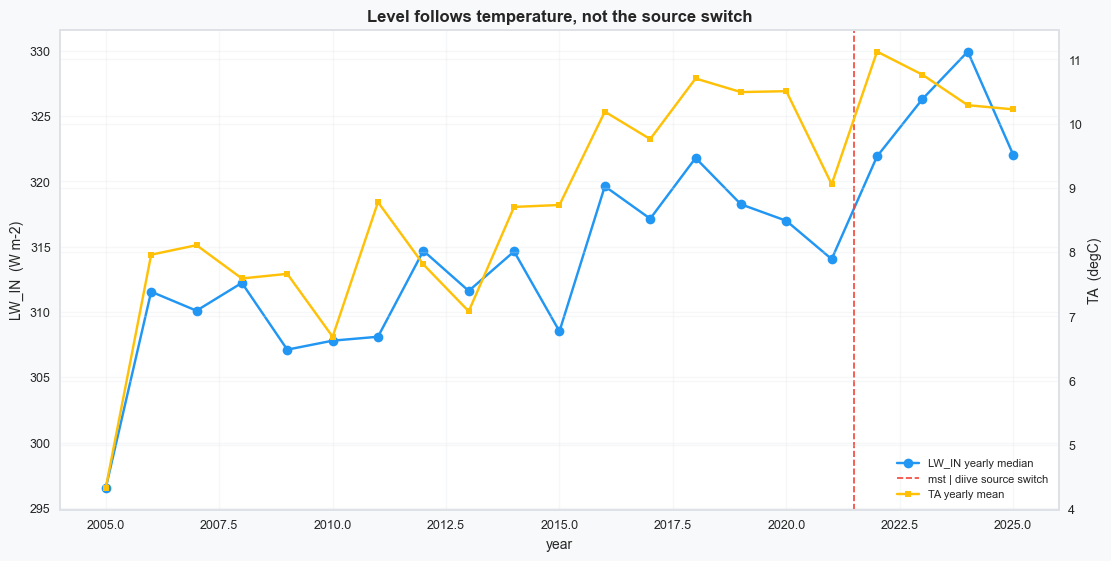

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=100, layout='constrained')

_lw_yr.plot(ax=ax, marker='o', color='#2196F3', label='LW_IN yearly median')
ax.set_ylabel('LW_IN  (W m-2)')
ax.set_xlabel('year')
ax.axvline(2021.5, color='#F44336', ls='--', lw=1.2, label='mst | diive source switch')
_ax2 = ax.twinx()
_ta_yr.plot(ax=_ax2, marker='s', ms=4, color='#FFC107', label='TA yearly mean')
_ax2.set_ylabel('TA  (degC)')
ax.set_title('Level follows temperature, not the source switch', fontsize=12)
_h1, _l1 = ax.get_legend_handles_labels()
_h2, _l2 = _ax2.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc='lower right')

***

# ❇️ Merge onto one continuous 30MIN index

The index starts at the first `LW_IN` measurement (2005-09-14), not at 2004-01-01. The two sources
do not overlap, so `combine_first` concatenates them; it is used rather than `concat` so that any
future overlap would resolve to `mst` deterministically instead of duplicating timestamps.

In [11]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
lw_2005_2025 = pd.DataFrame(index=full_index)
lw_2005_2025[TARGET] = (mst_lw[TARGET].reindex(full_index)
                        .combine_first(diive_lw[TARGET].reindex(full_index)))

print(f"{TARGET}: {lw_2005_2025[TARGET].notna().sum():,} of {len(lw_2005_2025):,} records "
      f"({100 * lw_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"first measurement: {lw_2005_2025[TARGET].first_valid_index()}")
lw_2005_2025

LW_IN_T1_47_1: 352,171 of 355,872 records (98.96%)
first measurement: 2005-09-14 13:15:00


,LW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,210.420480
2025-12-31 22:15:00,210.648200
2025-12-31 22:45:00,211.147057


## Plot: the merged series

As in notebook `05`, the date/time heatmap is really a **coverage** plot here. `LW_IN` does have a
diurnal cycle, but a weak one: averaged over 2006-2020 the amplitude is about 16 W m-2, against a
day-to-day standard deviation of daily means of about 29 W m-2. Longwave is driven mainly by cloud
and air mass, which vary synoptically, not by the sun angle. The consequence matters later: a
timestamp error cannot be diagnosed from this heatmap the way it can for `SW_IN`.

Text(0.5, 1.0, 'Mean diurnal cycle 2006-2020: amplitude only 16.1 W m-2')

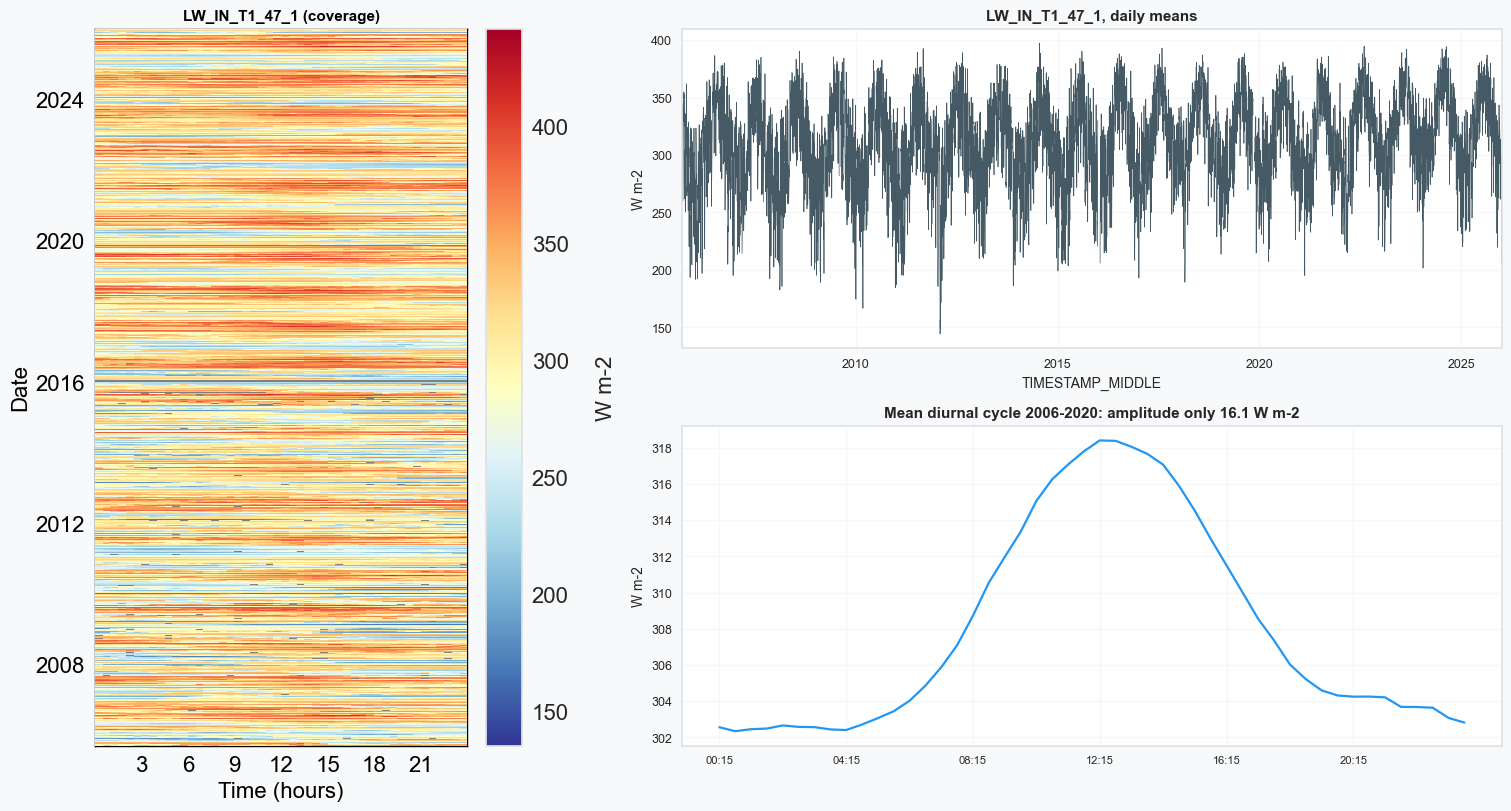

In [12]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_di = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=lw_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET} (coverage)', title_fontsize=11))

lw_2005_2025[TARGET].resample('1D').mean().plot(ax=ax_ts, lw=0.5, color='#455A64')
ax_ts.set_ylabel('W m-2')
ax_ts.set_title(f'{TARGET}, daily means', fontsize=11)

_dc = lw_2005_2025.loc['2006':'2020', TARGET]
_dc = _dc.groupby(_dc.index.time).mean()
ax_di.plot(range(len(_dc)), _dc.values, color='#2196F3', lw=1.6)
ax_di.set_xticks(range(0, len(_dc), 8))
ax_di.set_xticklabels([str(t)[:5] for t in _dc.index[::8]], fontsize=8)
ax_di.set_ylabel('W m-2')
ax_di.set_title(f'Mean diurnal cycle 2006-2020: amplitude only '
                f'{_dc.max() - _dc.min():.1f} W m-2', fontsize=11)

***

# ✴️ Corrections

### Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects **every variable that logger recorded**.
`LW_IN_T1_47_1` sits on tower 1 at 47 m, on the same acquisition system as `SW_IN_T1_47_1`,
`TA_T1_47_1`, `PPFD_IN_T1_47_1` and `PA_T1_47_1`, so the same `+15.5 h` correction is applied.

::: {.callout-warning title="This correction is applied on provenance, and cannot be verified from LW_IN itself"}
The other notebooks each had a way to *check* the shift:

- `01` (`SW_IN`) against **solar geometry** — radiation must peak at solar noon, so a 15.5 h error
  is glaring.
- `02` (`TA`) and `05` (`PA`) against an **independent NABEL instrument** on a different
  acquisition system.

`LW_IN` has neither. Its diurnal cycle is ~16 W m-2 against synoptic swings several times larger,
so solar geometry gives almost no leverage, and there is no second pyrgeometer at the site.

Worse, the obvious internal check does not work either: the natural reference would be
`TA_T1_47_1`, but that sensor is **on the same logger**, so a clock error shifts longwave and
temperature together and leaves their relationship intact. An internal test cannot detect a shift
that moves all of its inputs equally.

So the justification here is **provenance, not measurement**: the fault is documented in the
fieldbook as a logger clock error, the logger is shared, and the shift has been independently
confirmed on that logger by three other variables — `SW_IN` against the sun, and `PA` against the
NABEL barometer (RMSE 0.324 -> 0.046 kPa on 11 August, see notebook `05`). Applying it to `LW_IN`
follows from the shift being a property of the *clock*, which is shared, rather than of any
instrument.

The plot below is shown for the record, not as evidence. Do not read it as a validation.
:::

In [13]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5

_df = lw_2005_2025.copy()
_before = _df[TARGET].copy()   # kept for the before/after plot

# Take the mis-stamped block and move it onto the correct time axis.
_series_shifted = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna()
_series_shifted.index = _series_shifted.index + pd.Timedelta(hours=SHIFT_HOURS)

# Clear everything between the start of the issue and the last shifted timestamp, then write the
# corrected values back. Same procedure as notebooks 01-03 and 05.
_df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
_df.loc[_series_shifted.index, TARGET] = _series_shifted

print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")
print("\nApplied on provenance (shared logger). LW_IN cannot confirm or refute this on its own - "
      "see the note above.")

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00

Applied on provenance (shared logger). LW_IN cannot confirm or refute this on its own - see the note above.


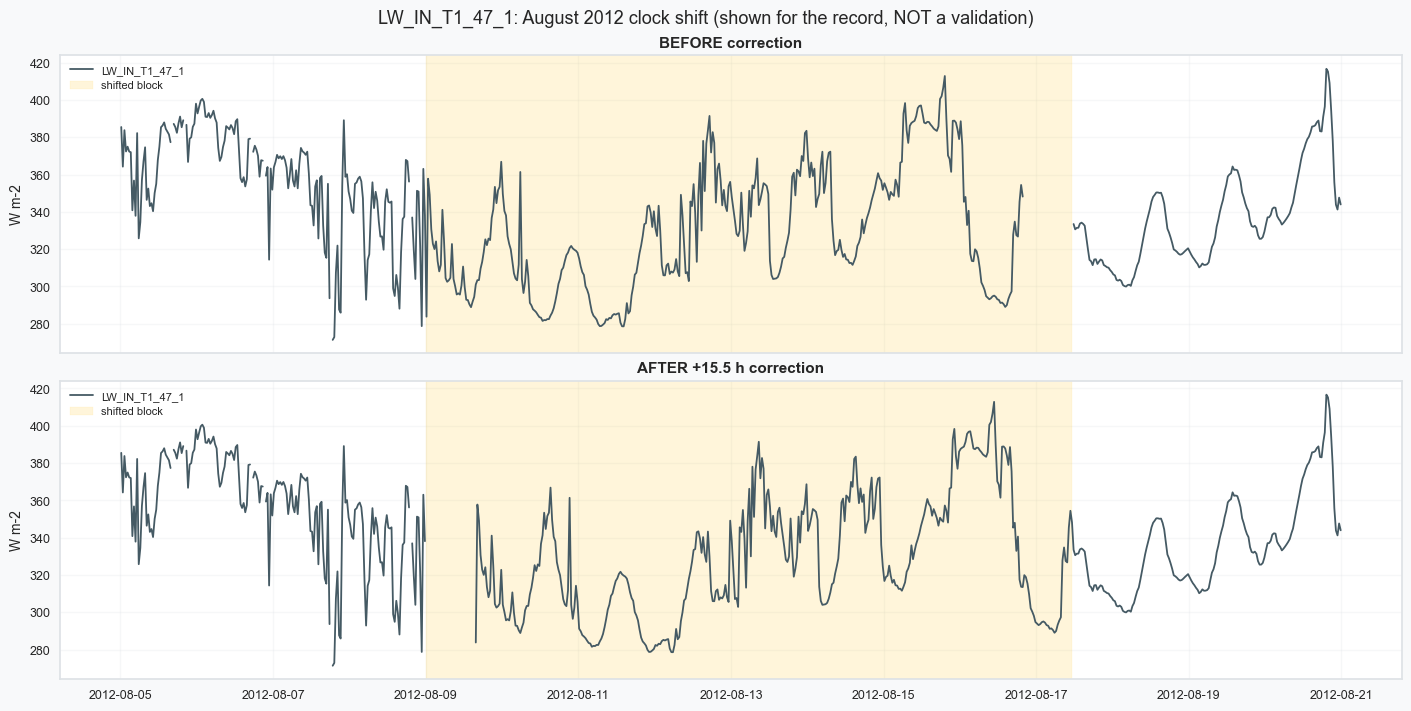

In [14]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift (shown for the record, NOT a validation)',
             fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

for _ax, _series, _title in [(axs[0], _before, 'BEFORE correction'),
                             (axs[1], _df[TARGET], f'AFTER +{SHIFT_HOURS} h correction')]:
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values, color='#455A64', lw=1.3,
             label=TARGET)
    _ax.axvspan(pd.Timestamp('2012-08-09'), pd.Timestamp('2012-08-17 11:15'),
                color='#FFC107', alpha=.15, label='shifted block')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='upper left')

In [15]:
lw_2005_2025 = _df.copy()
lw_2005_2025

,LW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,210.420480
2025-12-31 22:15:00,210.648200
2025-12-31 22:45:00,211.147057


### Damaged periods in 2012

Notebooks `01`, `02` and `03` remove three windows in 2012, caused by a tower power supply failure
in late July / early August and by storm damage and stressed cables in late October / early
November, both documented in the fieldbook:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

**`LW_IN` shows no internal sign of either fault.** That is a genuine null result and it is
reported here as one, because it is the honest description of the evidence:

| period | n | apparent emissivity, median [min..max] | outside 0.60-1.06 | flatlined records | dropouts |
|---|---|---|---|---|---|
| baseline, 1 Jun - 25 Jul | 2,619 | 0.877 | 0.00% | 0 | none |
| 29 Jul - 10 Aug (window 1) | 611 | 0.869 [0.719..1.060] | 0.00% | 0 | none |
| 28 Oct - 10 Nov (window 3) | 670 | 0.959 [0.686..1.032] | 0.00% | 0 | none |
| whole record 2006-2020 | — | 0.865 | 0.30% | — | — |

The sensor reported a full 48 records a day throughout, never froze, and stayed physically sensible
the whole time — by this metric the two suspect windows are *cleaner* than the record average.

**A null result is not an all-clear.** Three reasons it proves less than it appears to:

1. The emissivity check uses `TA_T1_47_1`, which is **on the same logger** and is itself degraded in
   exactly these windows (notebook `02` documents it). A ratio of two suspect quantities can look
   normal while both are wrong.
2. `LW_IN` varies from 135 to 442 W m-2 naturally, so a bias of tens of W m-2 hides inside ordinary
   weather. `PA` only exposed its fault because an independent barometer agreed to 0.04 kPa.
3. The fault in `PA` was a **level error**, not a dropout or a freeze — precisely the failure mode
   that this variable, without a reference, cannot see.

**Decision: the shared windows from `01`-`03` are removed.** With no evidence either way, the
conservative choice is to discard data that a documented, logger-wide fault could plausibly have
corrupted rather than keep it on the strength of a test known to be underpowered. `LW_IN` is a
47 m tower radiation sensor on the same system as `SW_IN`, which is unambiguously affected.

This is the **opposite** of the choice made for `PA` in notebook `05`, and deliberately so: there,
an independent barometer positively demonstrated that 28-29 October were sound, which justified
keeping them. Narrowing a window requires positive evidence of cleanliness, and absence of evidence
is not that. The windows here are therefore identical to `01`-`03`, including the 17-18 August
transitional tail.

In [16]:
# Identical to notebooks 01-03. Windows are on the CORRECTED time axis (after the +15.5 h shift).
# Kept deliberately wide: LW_IN has no independent reference, so there is no evidence on which to
# narrow them (unlike PA in notebook 05). See the discussion above.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

# The null result, computed rather than asserted, so a future re-run cannot silently disagree
# with the table above.
_emis_base = emissivity.loc['2012-06-01':'2012-07-25'].dropna()
print(f"{'period':<26} {'n':>6} {'emis median':>12} {'outside band':>13} {'flatlined':>10}")
for _lo, _hi, _lab in [('2012-06-01', '2012-07-25', 'baseline Jun-25Jul'),
                       ('2012-07-29', '2012-08-10', 'window 1 (power)'),
                       ('2012-10-28', '2012-11-10', 'window 3 (storm)')]:
    _e = emissivity.loc[_lo:_hi].dropna()
    _v = lw_2005_2025.loc[_lo:_hi, TARGET].dropna()
    print(f"{_lab:<26} {len(_e):>6,} {float(_e.median()):>12.3f} "
          f"{100 * ((_e < 0.60) | (_e > 1.06)).mean():>12.2f}% "
          f"{int(_v.diff().eq(0).sum()):>10}")

_before_n = int(lw_2005_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    lw_2005_2025.loc[_start:_end, TARGET] = np.nan
_removed = _before_n - int(lw_2005_2025[TARGET].notna().sum())
print(f"\nRemoved {_removed:,} records from {TARGET} on provenance grounds "
      f"(left as gaps, nothing is filled).")

period                          n  emis median  outside band  flatlined
baseline Jun-25Jul          2,619        0.877         0.00%          0
window 1 (power)              611        0.869         0.00%          0
window 3 (storm)              670        0.959         0.00%          0

Removed 1,202 records from LW_IN_T1_47_1 on provenance grounds (left as gaps, nothing is filled).


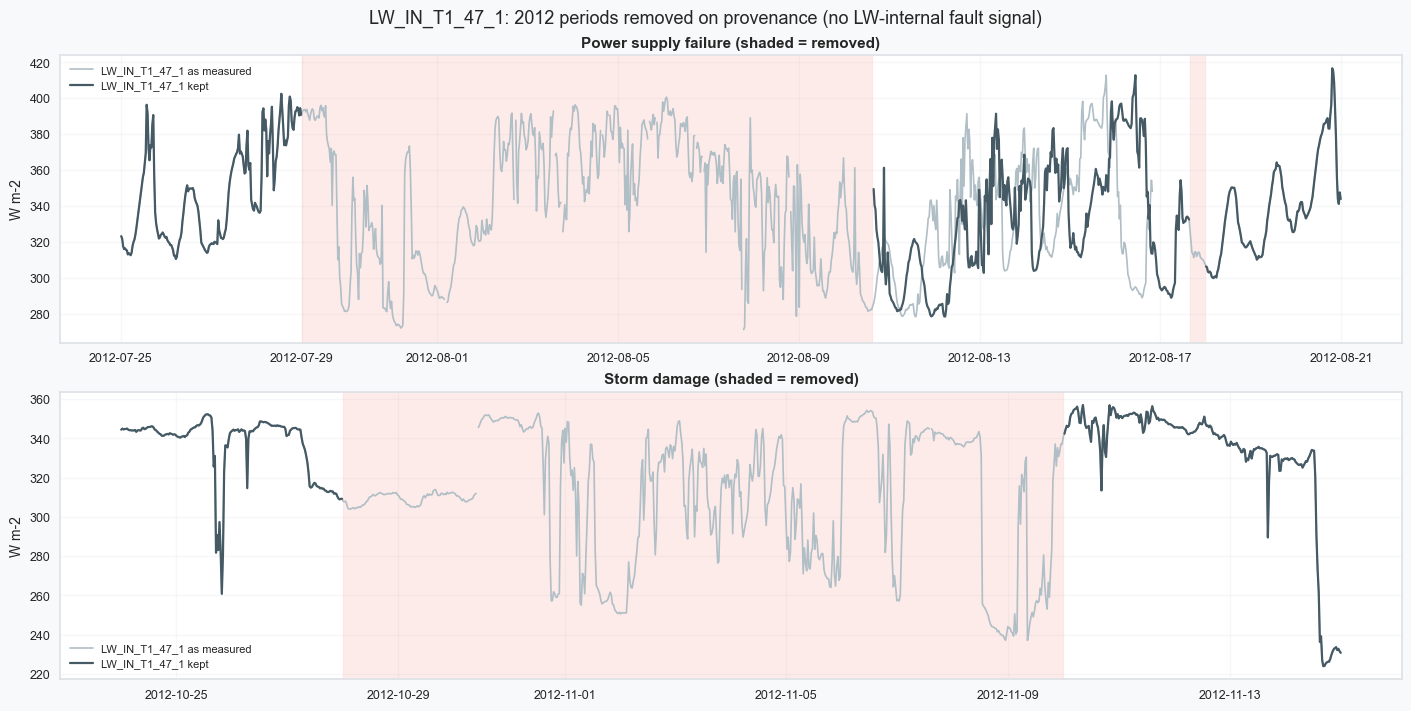

In [17]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 periods removed on provenance (no LW-internal fault signal)',
             fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-20', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(_before.loc[_w].index, _before.loc[_w].values, color='#B0BEC5', lw=1.2,
             label=f'{TARGET} as measured')
    _ax.plot(lw_2005_2025[TARGET].loc[_w].index, lw_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='best')

::: {.callout-note title="No nighttime zero-offset correction here, for a different reason than in 05"}
Notebooks `01` and `03` remove a nighttime zero-offset from `SW_IN` and `PPFD_IN`, because those
quantities have a known true value at night — zero — so any nonzero nighttime reading is measurable
sensor offset.

`LW_IN` is a radiation quantity too, but that correction would be **physically wrong** here.
Downwelling longwave is thermal emission from the atmosphere and continues all night; at this site
it is typically 250-350 W m-2 at 03:00. Forcing nighttime `LW_IN` to zero would destroy roughly half
the record. This is a sharper distinction than in notebook `05`, where `PA` simply had no reference
value at any time of day: here the variable *is* radiation and *does* have a diurnal cycle, and the
correction is still inapplicable.

As in `05`, the trap from notebook `03` — a correction writing into gaps and thereby relabelling
fills as measurements — **cannot occur here**: no correction writes a value into a missing record.
The clock shift moves existing records, and the 2012 windows only ever set values to `NaN`.
:::

## Dataframe

In [18]:
display(lw_2005_2025)
lw_2005_2025.describe()

,LW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,210.420480
2025-12-31 22:15:00,210.648200
2025-12-31 22:45:00,211.147057


,LW_IN_T1_47_1
count,350969.000000
mean,310.568035
std,45.568588
min,135.445129
25%,282.447887
50%,315.847198
75%,343.420273
max,441.779694


***

# 🚫 No gap-filling here

As in notebook `05`, the series is exported as measured.

The measured record is **98.96% complete** before the 2012 removals and 98.62% after them. Of 1,010
gaps, 991 are one hour or shorter; only 6 exceed a day, and the longest (20.6 days) is a site-wide
outage that `PA` shares.

Consequences for anything consuming this file:

- `LW_IN_T1_47_1` **contains `NaN`**. Code that assumes a complete series will break or silently
  propagate `NaN`.
- There is **no `FLAG_..._ISFILLED` column**, because there is nothing to flag. Non-null means
  measured.
- If a complete series is needed later, fill it downstream where the fill can be flagged in that
  product's own terms. Note that `LW_IN` is a comparatively easy fill — it is smooth and strongly
  tied to air temperature and cloudiness — but that is a downstream decision, not this notebook's.

***

# ➡️ Prepare dataframe for export

In [19]:
VALCOL = TARGET

# TA was a diagnostic only and is not exported.
export_df = lw_2005_2025[[VALCOL]].copy()
export_df

,LW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,210.420480
2025-12-31 22:15:00,210.648200
2025-12-31 22:45:00,211.147057


Sanity check. As in notebook `05` the series is **not** expected to be complete, so the check is
that the index is sound, every present value is physically plausible longwave, and the gaps are the
ones we know about.

In [20]:
_lo, _hi = LW_IN_PLAUSIBLE_WM2

print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} W m-2")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df[VALCOL].min() >= _lo and export_df[VALCOL].max() <= _hi, \
    f"values outside {_lo}-{_hi} W m-2"
assert export_df[VALCOL].notna().any(), "no data at all"
print("\nAll checks passed.")

export_df.describe()

Records:          355,872
Measured:         350,969 (98.62%)
Missing (NaN):    4,903 (1.38%)
Duplicate index:  0
Index gaps:       0
Index:            2005-09-14 00:15:00 -> 2025-12-31 23:45:00
Min / max:        135.45 / 441.78 W m-2

All checks passed.


,LW_IN_T1_47_1
count,350969.000000
mean,310.568035
std,45.568588
min,135.445129
25%,282.447887
50%,315.847198
75%,343.420273
max,441.779694


## Per-year statistics

`coverage_%` shows where the real gaps are: 2012 is the year of the removed fault periods, and
2009, 2016 and 2019 have sensor outages that are left as gaps. 2005 is a partial year by
construction, since the record starts on 14 September, which is also why its median is the lowest in
the table — it covers only autumn.

The `source` column marks the mst / diive boundary. The level rises across it, and the check above
showed that rise is explained by air temperature rather than by the source switch.

In [21]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
_yr['source'] = np.where(_yr.index <= 2021, 'mst', 'diive')
display(_yr.round(2))

_med = _yr['median']
assert ((_med > _lo) & (_med < _hi)).all(), "a yearly median is outside the plausible band"
print(f"All yearly medians between {_med.min():.2f} and {_med.max():.2f} W m-2.")
print(f"Full-year medians (2006-2025) span {_med.loc[2006:].min():.2f} to "
      f"{_med.loc[2006:].max():.2f} W m-2, sd {_med.loc[2006:].std():.2f}.")

,count,median,min,max,std,possible,coverage_%,source
TIMESTAMP_MIDDLE,,,,,,,,
2005,5184,296.53,166.98,387.15,44.45,5232,99.08,mst
2006,17396,311.56,160.44,415.70,50.49,17520,99.29,mst
2007,17422,310.10,164.10,411.22,46.83,17520,99.44,mst
2008,17423,312.23,164.83,410.42,49.23,17568,99.17,mst
2009,16917,307.12,149.90,414.92,46.90,17520,96.56,mst
2010,17291,307.81,149.98,420.89,47.11,17520,98.69,mst
2011,17472,308.11,170.92,411.45,47.08,17520,99.73,mst
2012,16210,314.01,135.45,419.37,50.73,17568,92.27,mst
2013,17362,311.62,169.86,441.78,45.75,17520,99.10,mst


All yearly medians between 296.53 and 329.94 W m-2.
Full-year medians (2006-2025) span 307.12 to 329.94 W m-2, sd 6.43.


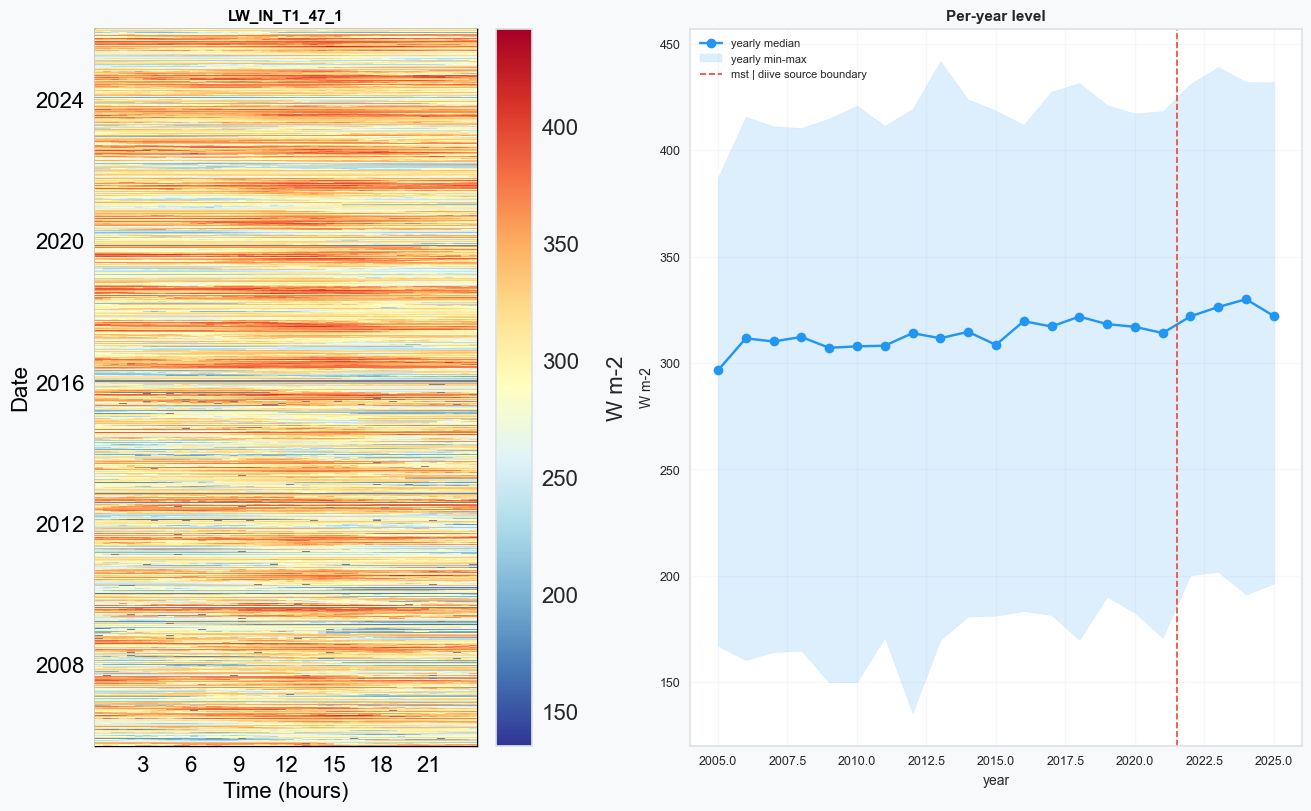

In [22]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['median'].plot(ax=axs[1], marker='o', color='#2196F3', label='yearly median')
axs[1].fill_between(_yr.index, _yr['min'], _yr['max'], color='#2196F3', alpha=.15,
                    label='yearly min-max')
axs[1].axvline(2021.5, color='#F44336', ls='--', lw=1.2, label='mst | diive source boundary')
axs[1].set_ylabel('W m-2')
axs[1].set_xlabel('year')
axs[1].set_title('Per-year level', fontsize=11)
axs[1].legend(fontsize=8)

***

# 💾 Save to file

In [23]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\06_METEO
_LW_IN_2005-2025.parquet (0.055 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\06_METEO_LW_IN_2005-2025.parquet


## Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [24]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.2f} W m-2")
print(f"min / max: {float(_written[VALCOL].min()):.2f} / {float(_written[VALCOL].max()):.2f} W m-2")

assert list(_written.columns) == [VALCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write"
assert _lo < float(_written[VALCOL].median()) < _hi, "median outside plausible range"
print("\nWritten file verified.")

display(_written[VALCOL].groupby(_written.index.year).median().round(2)
        .rename('yearly median (W m-2)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\06_METEO
_LW_IN_2005-2025.parquet (0.027 seconds).

columns:   ['LW_IN_T1_47_1']
index:     2005-09-14 00:15:00 -> 2025-12-31 23:45:00  (355,872 records)
measured:  350,969 (98.62%)
median:    315.85 W m-2
min / max: 135.45 / 441.78 W m-2

Written file verified.


TIMESTAMP_MIDDLE
2005    296.53
2006    311.56
2007    310.10
2008    312.23
2009    307.12
2010    307.81
2011    308.11
2012    314.01
2013    311.62
2014    314.64
2015    308.52
2016    319.63
2017    317.14
2018    321.79
2019    318.25
2020    316.99
2021    314.05
2022    321.91
2023    326.30
2024    329.94
2025    322.06
Name: yearly median (W m-2), dtype: float64

***

# End of notebook.

In [25]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-20 02:45:43
Finished: 2026-07-20 02:46:09
Runtime:  00:00:26 (hh:mm:ss)
